<a href="https://colab.research.google.com/github/jyryu3161/chembigdata/blob/main/lec06_cheminformatics_rdkit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lec05 Cheminformatics 실습 (RDKit)

강의자료 순서대로 따라가는 초보자용 노트북입니다.

다루는 내용
1. 분자 표현 (SMILES, InChI, molfile)
2. 분자 그래프
3. Fingerprint (MACCS, Morgan/ECFP)
4. 유사도 / 부분구조 검색
5. Molecular descriptors

셀은 위에서부터 순서대로 실행하세요.

## 0. 설치와 import

Colab에서 한 번만 실행하면 됩니다.

In [ ]:
!pip install -q rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 34.8 MB/s eta 0:00:00


In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem, Draw, Descriptors, rdMolDescriptors, DataStructs
from rdkit.Chem.Draw import IPythonConsole
from IPython.display import display

IPythonConsole.ipython_useSVG = True

## 1. 분자 표현법 (Molecular Representation)

컴퓨터는 그림이 아니라 **문자열/표**로 분자를 저장합니다.

- Linear notation: SMILES, InChI, InChIKey (한 줄의 텍스트로 압축)
- Connection table: molfile, SDF (하나의 파일로 표현, 원자들의 2D/3D 좌표와 결합 목록)

예제 분자: acetaminophen (타이레놀 성분)

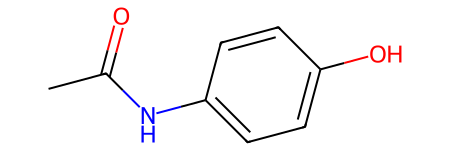

In [ ]:
smi = "CC(=O)Nc1ccc(O)cc1"   # acetaminophen
mol = Chem.MolFromSmiles(smi)
mol

In [ ]:
print("입력 SMILES :", smi)
print("원자 수 (수소 제외)  :", mol.GetNumAtoms()) # 11개 (C:8, N:1, O:2)
print("결합 수 (수소 제외)  :", mol.GetNumBonds())

# 참고: 실제 수소까지 포함한 전체 원자 수를 보려면 Chem.AddHs()를 사용
print("전체 원자 수 (수소 포함):", Chem.AddHs(mol).GetNumAtoms())  # 20개 (C:8, H:9, N:1, O:2)

입력 SMILES : c1ccccc1
원자 수 (수소 제외)  : 11
결합 수 (수소 제외)  : 11
전체 원자 수 (수소 포함): 20


## 2. SMILES 기본

SMILES = Simplified Molecular Input Line Entry System

같은 분자도 SMILES가 여러 개일 수 있습니다. 그래서 **canonical SMILES**를 씁니다.

CC1=CC(Br)CCC1


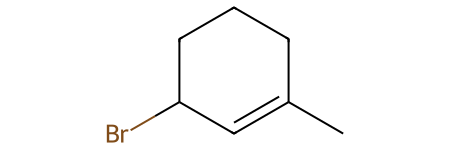

In [ ]:
# 강의 슬라이드 예제
mol_br = Chem.MolFromSmiles("CC1=CC(Br)CCC1") # 3-bromo-1-methylcyclohexene
print(Chem.MolToSmiles(mol_br))
mol_br

### Atom

- 원자 기호: `C`, `N`, `O`, `Cl`, `Br`
- 유기 원자(B, C, N, O, P, S, F, Cl, Br, I)는 보통 대괄호 생략
- 그 외 원자는 `[Au]`, `[Fe]`처럼 대괄호

In [ ]:
# methane CH4
mol_c = Chem.MolFromSmiles("C")
print("C의 수소 포함 원자 수:", Chem.AddHs(mol_c).GetNumAtoms())
print(Chem.MolToSmiles(mol_c))

# ammonia NH3
mol_n = Chem.MolFromSmiles("N")
print("N의 수소 포함 원자 수:", Chem.AddHs(mol_n).GetNumAtoms())
print(Chem.MolToSmiles(mol_n))

# gold atom
mol_au = Chem.MolFromSmiles("[Au]")
print("Au의 수소 포함 원자 수:", Chem.AddHs(mol_au).GetNumAtoms())
print(Chem.MolToSmiles(mol_au))

C의 수소 포함 원자 수: 5
C
N의 수소 포함 원자 수: 4
N
Au의 수소 포함 원자 수: 1
[Au]


### Bond

| 결합 | 기호 |
|---|---|
| 단일 | `-` (보통 생략) |
| 이중 | `=` |
| 삼중 | `#` |
| 방향족 | `:` (보통 생략, 소문자 원자)

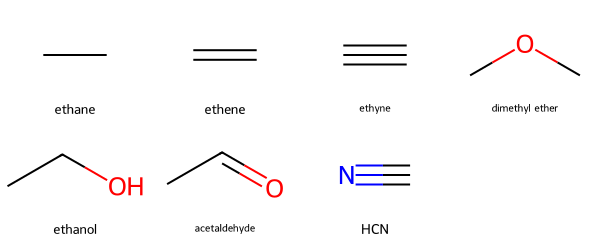

In [ ]:
examples = {
    "ethane": "CC",
    "ethene": "C=C",
    "ethyne": "C#C",
    "dimethyl ether": "COC",
    "ethanol": "CCO",
    "acetaldehyde": "CC=O",
    "HCN": "C#N",
}

mols = [Chem.MolFromSmiles(s) for s in examples.values()]
legends = list(examples.keys())
Draw.MolsToGridImage(mols, legends=legends, molsPerRow=4, subImgSize=(150, 120))

### Branches

가지(branch)는 괄호 `( )`로 씁니다.

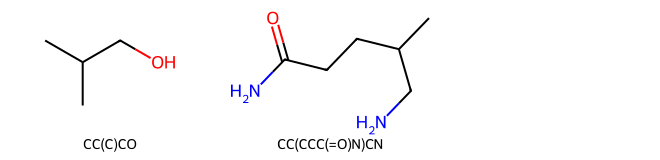

In [ ]:
m1 = Chem.MolFromSmiles("CC(C)CO")           # isobutanol
m2 = Chem.MolFromSmiles("CC(CCC(=O)N)CN")    # 5-amino-4-methylpentanamide
Draw.MolsToGridImage([m1, m2], legends=["CC(C)CO", "CC(CCC(=O)N)CN"], subImgSize=(220, 160))

### Rings

고리는 끊은 자리를 같은 숫자로 표시합니다.
방향족 고리는 원자를 소문자로 씁니다. `c1ccccc1` = benzene

cyclohexane: C1CCCCC1
benzene    : c1ccccc1


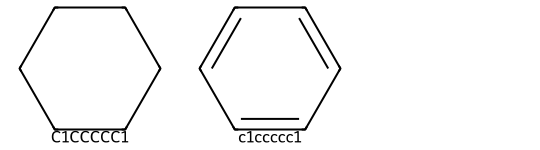

In [ ]:
cyclohexane = Chem.MolFromSmiles("C1CCCCC1")
benzene = Chem.MolFromSmiles("c1ccccc1")
print("cyclohexane:", Chem.MolToSmiles(cyclohexane))
print("benzene    :", Chem.MolToSmiles(benzene))
Draw.MolsToGridImage([cyclohexane, benzene], legends=["C1CCCCC1", "c1ccccc1"], subImgSize=(180, 150))

## 3. Isomeric SMILES (입체화학)

- 원자 입체: `@` (한 방향), `@@` (반대 방향)
- 이중결합 입체: `/`, `\\`

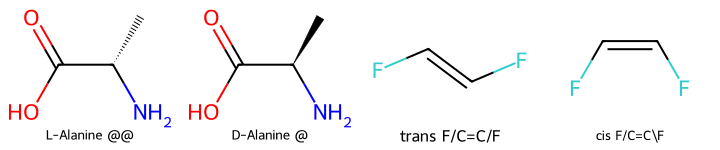

In [ ]:
L_ala = Chem.MolFromSmiles("C[C@@H](C(=O)O)N")
D_ala = Chem.MolFromSmiles("C[C@H](C(=O)O)N")
trans = Chem.MolFromSmiles("F/C=C/F")
cis = Chem.MolFromSmiles("F/C=C\\F")

Draw.MolsToGridImage(
    [L_ala, D_ala, trans, cis],
    legends=["L-Alanine @@", "D-Alanine @", "trans F/C=C/F", "cis F/C=C\\F"],
    molsPerRow=4,
    subImgSize=(180, 150),
)

## 4. Canonical vs Randomized SMILES

- Canonical: 같은 분자 → 항상 같은 문자열 (검색, DB)
- Randomized: 같은 분자 → 여러 문자열 (ML data augmentation)

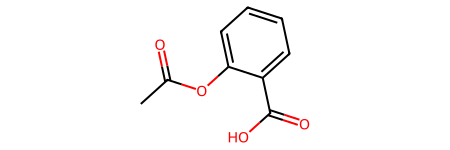

canonical : CC(=O)Oc1ccccc1C(=O)O

random 5개:
O=C(C)Oc1c(cccc1)C(=O)O
c1c(OC(C)=O)c(C(=O)O)ccc1
c1ccc(C(O)=O)c(OC(=O)C)c1
O=C(Oc1ccccc1C(O)=O)C
CC(Oc1c(C(O)=O)cccc1)=O


In [ ]:
mol = Chem.MolFromSmiles("CC(=O)Oc1ccccc1C(=O)O")  # aspirin
display(mol)
print("canonical :", Chem.MolToSmiles(mol))
print()
print("random 5개:")
for i in range(5):
    print(Chem.MolToSmiles(mol, doRandom=True))

## 5. InChI와 InChIKey

InChI는 층을 나눠 구조를 유일하게 적습니다.
InChIKey는 그걸 짧게 해시한 값이라 DB 검색에 자주 씁니다.

In [ ]:
mol = Chem.MolFromSmiles("CC(=O)Oc1ccccc1C(=O)O")
print("SMILES  :", Chem.MolToSmiles(mol))
print("InChI   :", Chem.MolToInchi(mol))
print("InChIKey:", Chem.MolToInchiKey(mol))

SMILES  : CC(=O)Oc1ccccc1C(=O)O
InChI   : InChI=1S/C9H8O4/c1-6(10)13-8-5-3-2-4-7(8)9(11)12/h2-5H,1H3,(H,11,12)
InChIKey: BSYNRYMUTXBXSQ-UHFFFAOYSA-N


## 6. Connection Table (Molfile)

원자 목록 + 결합 목록입니다. SDF, MOL 파일의 핵심입니다.

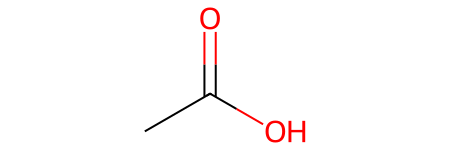


     RDKit          2D

  4  3  0  0  0  0  0  0  0  0999 V2000
    0.0000    0.0000    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    1.2990    0.7500    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    1.2990    2.2500    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
    2.5981   -0.0000    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
  1  2  1  0
  2  3  2  0
  2  4  1  0
M  END



In [ ]:
mol = Chem.MolFromSmiles("CC(=O)O")  # acetic acid
display(mol)
print(Chem.MolToMolBlock(mol))

# [Header Block]
# [Counts Line] - 원자 수, 결합 수 및 규격 플래그
# [Atom Block] - 원자별 2D/3D 좌표 (X, Y, Z) 및 원소 기호
# [Bond Block] - 연결된 원자 쌍 및 결합 차수 (1:단일, 2:이중)
# [Terminator] - 파일 종료 마커

## 7. 분자 그래프

분자 = 그래프 `G = (V, E)`
- 꼭짓점 V = 원자
- 간선 E = 결합

컴퓨터에서는 adjacency matrix로 자주 표현합니다.

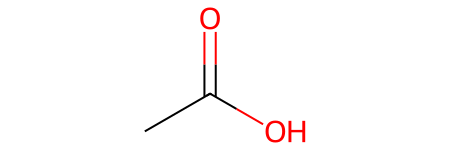

원자 순서:
0 C
1 C
2 O
3 O

결합:
0 - 1 SINGLE
1 - 2 DOUBLE
1 - 3 SINGLE


In [ ]:
mol = Chem.MolFromSmiles("CC(=O)O")  # acetic acid
display(mol)
print("원자 순서:")
for atom in mol.GetAtoms():
    print(atom.GetIdx(), atom.GetSymbol())

print("\n결합:")
for bond in mol.GetBonds():
    a = bond.GetBeginAtomIdx()
    b = bond.GetEndAtomIdx()
    print(a, "-", b, bond.GetBondType())

In [ ]:
from rdkit.Chem import rdmolops
import numpy as np

A = rdmolops.GetAdjacencyMatrix(mol)
print("--- 기본 Adjacency Matrix ---")
print(A)

A_bo = rdmolops.GetAdjacencyMatrix(mol, useBO=True)
print("\n--- 결합 차수가 반영된 Adjacency Matrix ---")
print(A_bo)

--- 기본 Adjacency Matrix ---
[[0 1 0 0]
 [1 0 1 1]
 [0 1 0 0]
 [0 1 0 0]]

--- 결합 차수가 반영된 Adjacency Matrix ---
[[0. 1. 0. 0.]
 [1. 0. 2. 1.]
 [0. 2. 0. 0.]
 [0. 1. 0. 0.]]


## 8. Molecular Fingerprints

구조를 고정 길이 숫자 벡터로 바꿉니다.
비슷한 분자끼리 빠르게 비교할 때 씁니다.

### 8-1. MACCS Keys

미리 정해 둔 166개 부분구조가 있는지(0/1) 표시합니다.
짧고 빠르지만, 다른 분자가 같은 fingerprint를 가질 수 있습니다 (collision).

In [ ]:
mol = Chem.MolFromSmiles("CC(=O)Nc1ccc(O)cc1")  # acetaminophen
fp = rdMolDescriptors.GetMACCSKeysFingerprint(mol)

print("길이:", fp.GetNumBits())          # 167 (0번은 비워 둠, 실제 key는 1~166)
print("켜진 bit 개수:", fp.GetNumOnBits())
print("켜진 bit 번호:", list(fp.GetOnBits())[:20], "...")

길이: 167
켜진 bit 개수: 23
켜진 bit 번호: [92, 110, 113, 117, 127, 131, 133, 135, 139, 143, 151, 152, 154, 156, 157, 158, 159, 160, 161, 162] ...


### 8-2. Morgan / ECFP

각 원자 주변을 반지름만큼 넓혀 가며 부분구조를 만들고, 해시해서 bit에 넣습니다.

- radius=0 → ECFP0
- radius=1 → ECFP2
- radius=2 → ECFP4 (가장 많이 씀)

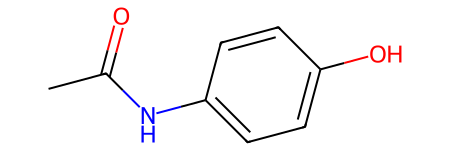

길이: 2048
켜진 bit 개수: 20
켜진 bit 번호: [191, 245, 530, 650, 745, 807, 843, 849, 1017, 1057, 1077, 1152, 1313, 1380, 1602, 1750, 1778, 1816, 1873, 1917]


[01:23:57] DEPRECATION WARNING: please use MorganGenerator


In [ ]:
mol = Chem.MolFromSmiles("CC(=O)Nc1ccc(O)cc1")
display(mol)
fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)

print("길이:", fp.GetNumBits())
print("켜진 bit 개수:", fp.GetNumOnBits())
print("켜진 bit 번호:", list(fp.GetOnBits()))

어떤 부분구조가 bit를 켰는지 그림으로 볼 수 있습니다.

예시 bit: 1077


[01:20:51] DEPRECATION WARNING: please use MorganGenerator


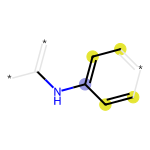

In [ ]:
from rdkit.Chem import rdMolDescriptors as rdmd

info = {}
fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048, bitInfo=info)
bit_id = list(info.keys())[10]
print("예시 bit:", bit_id)
Draw.DrawMorganBit(mol, bit_id, info)

# 파란색 원 (Blue dot): 해당 비트를 만든 중심 원자 (Center Atom)
# 노란색 하이라이트 영역: 중심 원자로부터 반경(radius)만큼 확장되어 비트 해시값 계산에 포함된 주변 원자 및 결합선
# 회색 선 (하이라이트 없음): 그 비트를 켜는 데 관여하지 않은 나머지 분자 영역

## 9. 유사도 검색 (Tanimoto / Jaccard)

$$J(A,B) = \frac{|A \cap B|}{|A \cup B|}$$

두 fingerprint에서 같이 1인 bit / 둘 중 하나라도 1인 bit.

In [ ]:
names = ["acetaminophen", "aspirin", "ibuprofen", "caffeine", "benzene"]
smiles = [
    "CC(=O)Nc1ccc(O)cc1",
    "CC(=O)Oc1ccccc1C(=O)O",
    "CC(C)Cc1ccc(C(C)C(=O)O)cc1",
    "Cn1c(=O)c2c(ncn2C)n(C)c1=O",
    "c1ccccc1",
]
mols = [Chem.MolFromSmiles(s) for s in smiles]
fps = [AllChem.GetMorganFingerprintAsBitVect(m, 2, nBits=2048) for m in mols]

query = fps[0]
sims = [DataStructs.TanimotoSimilarity(query, fp) for fp in fps]

print("query = acetaminophen\n")
for name, fp in zip(names, fps):
    sim = DataStructs.TanimotoSimilarity(query, fp)
    print(f"{name:15s}  Tanimoto = {sim:.3f}")

query = acetaminophen

acetaminophen    Tanimoto = 1.000
aspirin          Tanimoto = 0.222
ibuprofen        Tanimoto = 0.184
caffeine         Tanimoto = 0.098
benzene          Tanimoto = 0.045


[01:31:08] DEPRECATION WARNING: please use MorganGenerator
[01:31:08] DEPRECATION WARNING: please use MorganGenerator
[01:31:08] DEPRECATION WARNING: please use MorganGenerator
[01:31:08] DEPRECATION WARNING: please use MorganGenerator
[01:31:08] DEPRECATION WARNING: please use MorganGenerator


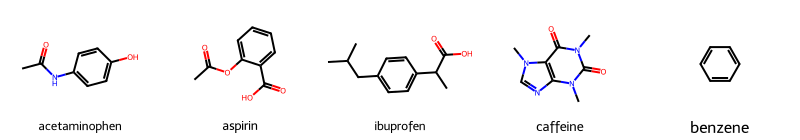

In [ ]:
Draw.MolsToGridImage(mols, legends=names, molsPerRow=5, subImgSize=(160, 140))

강의 슬라이드처럼 작은 벡터로 직접 계산해 봅니다.

`x = (1 0 0 1 0 0 0 0 0 0)`

`y = (0 0 0 1 0 0 1 0 0 1)`

- f11 = 같이 1인 자리 = 1
- f10 + f01 + f11 = 4
- J = 1 / 4 = 0.25

In [ ]:
x = [1, 0, 0, 1, 0, 0, 0, 0, 0, 0]
y = [0, 0, 0, 1, 0, 0, 1, 0, 0, 1]

f11 = sum(a == 1 and b == 1 for a, b in zip(x, y))
f10 = sum(a == 1 and b == 0 for a, b in zip(x, y))
f01 = sum(a == 0 and b == 1 for a, b in zip(x, y))
J = f11 / (f11 + f10 + f01)
print(f"f11, f10, f01 = {f11}, {f10}, {f01}")
print("Tanimoto =", J)

f11, f10, f01 = 1, 1, 2
Tanimoto = 0.25


## 10. Exact match / Substructure search

- Exact match: InChIKey 또는 canonical SMILES가 같은지
- Substructure: 쿼리 조각이 분자 안에 들어 있는지 (`HasSubstructMatch`)

In [ ]:
query_key = Chem.MolToInchiKey(Chem.MolFromSmiles("CC(=O)Nc1ccc(O)cc1"))
print("기준 분자(acetaminophen)의 InChIKey:")
print(query_key)
print("\n" + "=" * 35)
print("  [완전 일치(Exact Match)]")
print("=" * 35)

for name, smi in zip(names, smiles):
    key = Chem.MolToInchiKey(Chem.MolFromSmiles(smi))
    is_match = "일치 (동일 분자)" if key == query_key else "불일치"
    print(f"{name:15s} : {is_match}")

기준 분자(acetaminophen)의 InChIKey:
RZVAJINKPMORJF-UHFFFAOYSA-N

  [완전 일치(Exact Match)]
acetaminophen   : 일치 (동일 분자)
aspirin         : 불일치
ibuprofen       : 불일치
caffeine        : 불일치
benzene         : 불일치


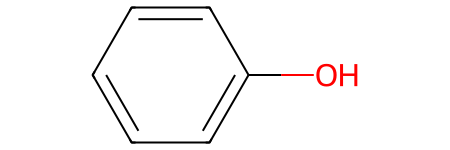

  [페놀(Phenol, c1ccccc1O) 조각 검색 결과]
acetaminophen   : 포함 (부분구조 발견)
aspirin         : 포함 (부분구조 발견)
ibuprofen       : 미포함
caffeine        : 미포함
benzene         : 미포함
---------------------------------------------
총 5개 중 2개 분자에서 페놀 골격 발견: ['acetaminophen', 'aspirin']


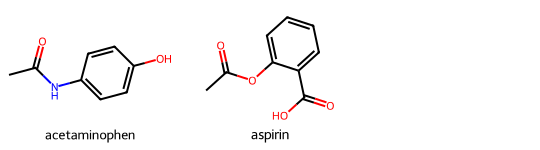

In [ ]:
phenol = Chem.MolFromSmiles("c1ccccc1O")   # 페놀 조각
display(phenol)

print("=" * 45)
print("  [페놀(Phenol, c1ccccc1O) 조각 검색 결과]")
print("=" * 45)

hits = []
hit_names = []

for name, m in zip(names, mols):
    # HasSubstructMatch(): 해당 부분구조를 분자 안에 포함하고 있는지 확인 (True/False)
    has_pattern = m.HasSubstructMatch(phenol)
    result_text = "포함 (부분구조 발견)" if has_pattern else "미포함"
    print(f"{name:15s} : {result_text}")

    if has_pattern:
        hits.append(m)
        hit_names.append(name)

print("-" * 45)
print(f"총 {len(mols)}개 중 {len(hits)}개 분자에서 페놀 골격 발견: {hit_names}")

# 발견된 분자들만 시각화
Draw.MolsToGridImage(hits, legends=hit_names, subImgSize=(180, 150))

## 11. Molecular Descriptors

분자의 성질을 숫자로 바꾼 값입니다.
강의 표에 나온 항목을 RDKit으로 계산합니다.

In [ ]:
mol = Chem.MolFromSmiles("CC(=O)Nc1ccc(O)cc1")

print("MW      :", Descriptors.MolWt(mol))                  # 분자량 (Molecular Weight, Da)
print("nHDon   :", Descriptors.NumHDonors(mol))              # 수소결합 공여체 수 (H-Donors: -OH, -NH- 등)
print("nHAcc   :", Descriptors.NumHAcceptors(mol))            # 수소결합 수용체 수 (H-Acceptors: O, N 등)
print("TPSA    :", Descriptors.TPSA(mol))                    # 극성 표면적 (Polar Surface Area, 세포막·BBB 투과율 지표)
print("nSK     :", mol.GetNumHeavyAtoms())                   # 골격 중원자 수 (Heavy Atoms: 수소를 제외한 원자 수)
print("RBN     :", Descriptors.NumRotatableBonds(mol))        # 회전 가능한 단일결합 수 (분자의 유연성 지표)
print("cLogP   :", Descriptors.MolLogP(mol))                  # 옥탄올/물 분배계수 (지용성·친유성 척도)
print("nAR     :", rdMolDescriptors.CalcNumAromaticRings(mol)) # 방향족 고리 개수 (Aromatic Rings)
print("Fsp3    :", Descriptors.FractionCSP3(mol))             # sp3 탄소 비율 (전체 탄소 중 sp3 비율, 3차원 입체성 지표)

MW      : 151.165
nHDon   : 2
nHAcc   : 2
TPSA    : 49.33
nSK     : 11
RBN     : 1
cLogP   : 1.3505999999999998
nAR     : 1
Fsp3    : 0.125


In [ ]:
import pandas as pd

rows = []
for name, m in zip(names, mols):
    rows.append({
        "name": name,
        "MW": round(Descriptors.MolWt(m), 2),
        "LogP": round(Descriptors.MolLogP(m), 2),
        "TPSA": round(Descriptors.TPSA(m), 2),
        "HBD": Descriptors.NumHDonors(m),
        "HBA": Descriptors.NumHAcceptors(m),
        "RotB": Descriptors.NumRotatableBonds(m),
        "Fsp3": round(Descriptors.FractionCSP3(m), 3),
    })

pd.DataFrame(rows)

,name,MW,LogP,TPSA,HBD,HBA,RotB,Fsp3
0,acetaminophen,151.16,1.35,49.33,2,2,1,0.125
1,aspirin,180.16,1.31,63.60,1,3,2,0.111
2,ibuprofen,206.28,3.07,37.30,1,1,4,0.462
3,caffeine,194.19,-1.03,61.82,0,3,0,0.375
4,benzene,78.11,1.69,0.00,0,0,0,0.000


## 12. (선택) molfeat로 feature 한 줄에 만들기

강의 마지막 슬라이드 링크: https://molfeat.datamol.io/featurizers

RDKit만으로도 실습은 충분합니다. 더 많은 featurizer가 필요하면 아래를 실행하세요.

In [ ]:
# 필요하면 주석을 풀고 실행
!pip install -q --no-warn-conflicts molfeat
from molfeat.trans.fp import FPVecTransformer
feat = FPVecTransformer("ecfp", length=2048) # ECFP fingerprint를 2048비트 길이로 뽑는 변환기 생성
X = feat(["CC(=O)Nc1ccc(O)cc1", "CC(=O)Oc1ccccc1C(=O)O"])
print(X.shape) # (분자 수, fingerprint 길이)

(2, 2048)


## 연습

1. 본인 관심 약물 SMILES를 넣어 그림을 그리세요.
2. acetaminophen과의 Tanimoto 유사도를 계산하세요.
3. `c1ccccc1` (benzene) 부분구조가 있는지 확인하세요.
4. MW, LogP, TPSA를 출력하세요.

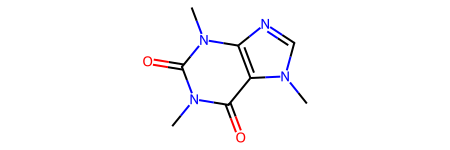

acetaminophen과의 Tanimto: 0.098
benzene 부분구조가 있는지? False
MW      : 194.194
LogP    : -1.0293
TPSA    : 61.82


[01:47:55] DEPRECATION WARNING: please use MorganGenerator
[01:47:55] DEPRECATION WARNING: please use MorganGenerator


In [ ]:
my_smi = "CN1C=NC2=C1C(=O)N(C(=O)N2C)C"   # 예시: caffeine로 바꿔 연습
my_mol = Chem.MolFromSmiles(my_smi)
display(my_mol)

ref = AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles("CC(=O)Nc1ccc(O)cc1"), 2, 2048)
fp = AllChem.GetMorganFingerprintAsBitVect(my_mol, 2, 2048)
print("acetaminophen과의 Tanimto:", round(DataStructs.TanimotoSimilarity(ref, fp), 3))
print("benzene 부분구조가 있는지?", my_mol.HasSubstructMatch(Chem.MolFromSmiles("c1ccccc1")))
print("MW      :", Descriptors.MolWt(my_mol))
print("LogP    :", Descriptors.MolLogP(my_mol))
print("TPSA    :", Descriptors.TPSA(my_mol))